In [9]:
# Import Libraries

# Data Management
import pandas as pd
import numpy as np

# Plots
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from statsmodels.iolib.table import SimpleTable
import statsmodels.api as sm

# Data
import yfinance as yf

# Handle Files
import sys
import os

# Import Local Functions
sys.path.append(os.path.abspath("source"))
from other_data_functions import wexp
from regression_toolkit import add_constant
from factors_toolkit import compute_factor_contributions
from factors_toolkit import compute_residual_returns
from portfolios_helper import calculate_analytics

# Example 1

In [10]:
# Import Momentum Portfolio
momentum = pd.read_csv(r'additional_data/momentum_portfolio.csv')
momentum.set_index('Date', inplace=True)
momentum.index.name = 'date'
momentum.columns = ['momentum_returns']
momentum.index = pd.to_datetime(momentum.index)

In [11]:
# Import Benchmark (SP500)
benchmark = pd.read_csv(r'additional_data/benchmark_returns.csv')
benchmark.set_index('Date', inplace=True)
benchmark.index.name = 'date'
benchmark.index = pd.to_datetime(benchmark.index)

In [12]:
# Comparison DataFrame
mom_vs_benchmark = pd.concat([momentum, benchmark], axis=1)
mom_vs_benchmark = mom_vs_benchmark.loc['2000':]

mom_vs_benchmark

,momentum_returns,benchmark_returns
date,,
2000-01-03,0.013859,-0.009595
2000-01-04,-0.026748,-0.039099
2000-01-05,-0.012554,0.001920
2000-01-06,-0.023430,0.000955
2000-01-07,0.011877,0.026730
...,...,...
2024-12-24,0.004636,0.010982
2024-12-26,-0.002000,-0.000406
2024-12-27,-0.003890,-0.011117


In [13]:
analytics = calculate_analytics(mom_vs_benchmark)
analytics = analytics.T
analytics.reset_index(inplace=True)
analytics

,index,momentum_returns,benchmark_returns
0,Annualized Returns,4.320778,5.558032
1,Annualized Volatility,16.214286,19.420244
2,Sharpe Ratio,0.266480,0.286198
3,Max Drawdown,-52.012056,-52.578452
4,VaR 95%,-1.522077,-1.874735


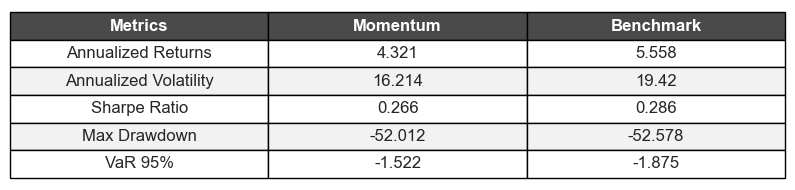

In [14]:
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis("off")  # hide axes

# Styled table
table = ax.table(
    cellText=analytics.round(3).values,
    colLabels=['Metrics', 'Momentum', 'Benchmark'],
    cellLoc="center",
    loc="center"
)

# Font size and scaling
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)  # make it a bit larger

# Header styling
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor("#4a4a4a")  # dark gray header
    elif row % 2 == 0:
        cell.set_facecolor("#f2f2f2")  # light gray for zebra stripes

# Remove table borders for a clean look
for _, cell in table.get_celld().items():
    cell.set_edgecolor("black")

plt.tight_layout()
plt.show()

In [15]:
# Data and headers
data = analytics.round(3).values.tolist()
headers = ['Metrics', 'Momentum', 'Benchmark']

# Create table
table = SimpleTable(
    data,
    headers=headers,
    title="Portfolio Analytics"
)

print(table)

          Portfolio Analytics           
       Metrics        Momentum Benchmark
----------------------------------------
   Annualized Returns    4.321     5.558
Annualized Volatility   16.214     19.42
         Sharpe Ratio    0.266     0.286
         Max Drawdown  -52.012   -52.578
              VaR 95%   -1.522    -1.875
----------------------------------------


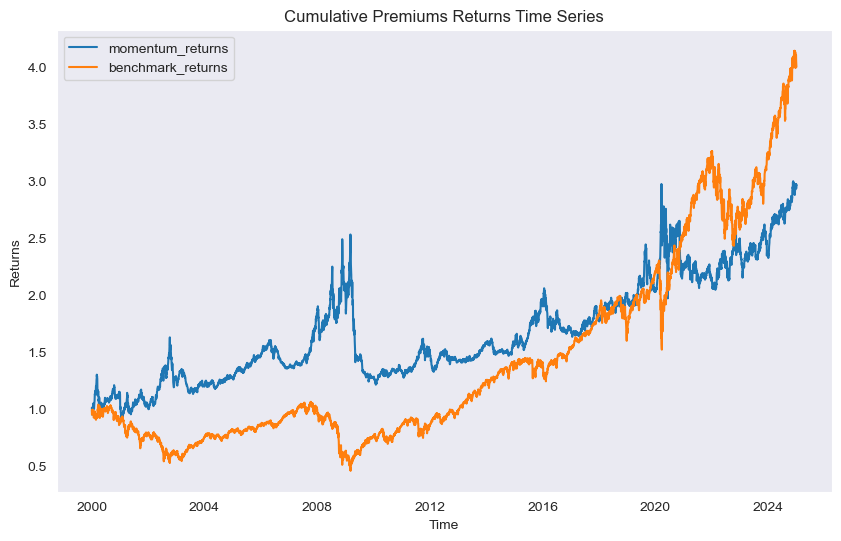

In [16]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(np.exp(mom_vs_benchmark.cumsum()), label=mom_vs_benchmark.columns, alpha=1)

# Config
plt.title('Cumulative Premiums Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()
plt.grid()

# Show
plt.show()

Mencionar:

1) Qué es Momentum (capaz como se calcula)
2) Cómo es que surge la preocupación por Momentum (Carhart vs. Hipótesis de los Mercados Eficientes)
3) Por qué se invierte luego de pandemia

# Example 2

In [17]:
index_tickers = ['SSO', 'SPXL', 'UPRO', 'SPY']

In [18]:
# Import data
index_prices = pd.DataFrame()

for ticker in index_tickers:
    data = yf.download(
        ticker,                     # Stock to import
        start='2010-01-01',         # First Date
        end='2025-01-01',           # Last Date
        interval='1d',              # Daily Basis
        auto_adjust=True,           # Adjusted Prices,
        progress=False              # Not printing
    )
    
    # Flat columns
    data.columns = data.columns.get_level_values(0)
    data.columns = data.columns.str.lower()
    
    close = data['close'].rename(ticker)
    
    index_prices = pd.concat([index_prices, close], axis=1)
    
    print(f'Data Ready for {ticker}')
    
index_prices.index = pd.to_datetime(index_prices.index)
index_prices

Data Ready for SSO
Data Ready for SPXL
Data Ready for UPRO
Data Ready for SPY


,SSO,SPXL,UPRO,SPY
2010-01-04,4.554520,4.081055,2.081381,85.279221
2010-01-05,4.584521,4.119498,2.099268,85.504959
2010-01-06,4.587984,4.130588,2.105317,85.565155
2010-01-07,4.626064,4.179384,2.130965,85.926361
2010-01-08,4.658373,4.223743,2.151746,86.212288
...,...,...,...,...
2024-12-24,97.104958,181.156418,95.505211,596.076965
2024-12-26,97.124870,181.166336,95.495255,596.116699
2024-12-27,95.053299,175.453125,92.450394,589.841614
2024-12-30,92.862206,169.353088,89.216476,583.110596


In [19]:
index_returns = np.log(index_prices) - np.log(index_prices.shift(1))
index_returns.dropna(inplace=True)
index_returns 

,SSO,SPXL,UPRO,SPY
2010-01-05,0.006566,0.009376,0.008557,0.002644
2010-01-06,0.000755,0.002688,0.002878,0.000704
2010-01-07,0.008266,0.011744,0.012109,0.004213
2010-01-08,0.006960,0.010558,0.009704,0.003322
2010-01-11,0.003215,0.003844,0.003540,0.001396
...,...,...,...,...
2024-12-24,0.020936,0.030746,0.031433,0.011054
2024-12-26,0.000205,0.000055,-0.000104,0.000067
2024-12-27,-0.021560,-0.032044,-0.032404,-0.010582
2024-12-30,-0.023321,-0.035386,-0.035606,-0.011477


In [20]:
# import risk free rate
risk_free_rate = pd.read_csv(r'additional_data/risk_free_rate.csv')
risk_free_rate.set_index('Date', inplace=True)
risk_free_rate.index.name = 'date'
risk_free_rate.index = pd.to_datetime(risk_free_rate.index)
risk_free_rate = risk_free_rate.loc['2010':]

risk_free_rate

,risk_free_rate
date,
2010-01-04,0.000107
2010-01-05,0.000104
2010-01-06,0.000106
2010-01-07,0.000106
2010-01-08,0.000106
...,...
2024-12-24,0.000128
2024-12-26,0.000127
2024-12-27,0.000128


In [21]:
excess_returns = index_returns.subtract(risk_free_rate['risk_free_rate'], axis = 0)
excess_returns.dropna(inplace=True)

excess_returns

,SSO,SPXL,UPRO,SPY
2010-01-05,0.006461,0.009272,0.008453,0.002539
2010-01-06,0.000649,0.002583,0.002772,0.000598
2010-01-07,0.008160,0.011638,0.012003,0.004106
2010-01-08,0.006854,0.010452,0.009598,0.003216
2010-01-11,0.003109,0.003738,0.003434,0.001290
...,...,...,...,...
2024-12-24,0.020808,0.030618,0.031305,0.010926
2024-12-26,0.000078,-0.000072,-0.000231,-0.000061
2024-12-27,-0.021688,-0.032172,-0.032533,-0.010711
2024-12-30,-0.023447,-0.035512,-0.035733,-0.011603


In [22]:
# Set the arrays
y_matrix = excess_returns.drop(columns='SPY')
x_matrix = excess_returns['SPY']

# Add constant
x_matrix = add_constant(x_matrix)

In [23]:
# We can use StatsModels efficiently to get the betas for the whole history
betas_list = []

# Loop to Obtain Betas and Alpha + Residuals
for ticker in y_matrix.columns:
    # Define series
    y_series = y_matrix[ticker].dropna()
    
    # Set the Window
    window = len(y_series)
    weights = window * wexp(window, window/2)
    
    # Define weights
    model = sm.WLS(y_series, x_matrix.loc[y_series.index], weights=weights)
    results = model.fit()
    
    beta = results.params.iloc[1]
    
    betas_list.append(beta)

# Create Beta Series
betas_series = pd.Series(betas_list, index=y_matrix.columns)
betas_series.name = 'history_beta'

betas_series

SSO     2.017077
SPXL    3.027861
UPRO    3.039363
Name: history_beta, dtype: float64

In [24]:
# Cut DataFrames
stock = 'UPRO'

stock_beta = betas_series[stock]
r_i = y_matrix[stock]
r_m = x_matrix['SPY']

In [25]:
# Calculate factor returns
r_f = compute_factor_contributions(r_m, stock_beta)

# Calculate residual returns
residual_returns = compute_residual_returns(r_i, r_m, stock_beta)
residual_returns.name = 'residual_returns'

residual_returns

2010-01-05    0.000735
2010-01-06    0.000954
2010-01-07   -0.000478
2010-01-08   -0.000177
2010-01-11   -0.000486
                ...   
2024-12-24   -0.001903
2024-12-26   -0.000047
2024-12-27    0.000021
2024-12-30   -0.000466
2024-12-31   -0.000105
Name: residual_returns, Length: 3773, dtype: float64

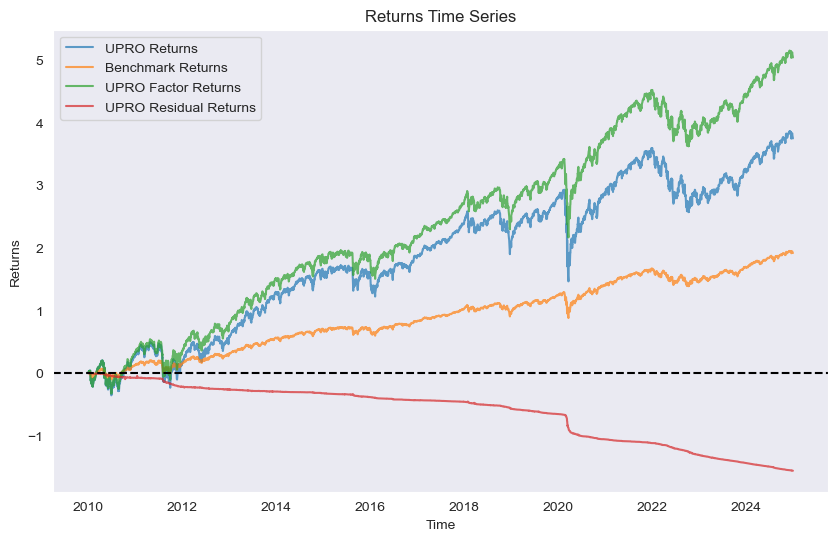

In [26]:
# Create the Plot
plt.figure(figsize=(10, 6))
plt.plot(index_returns[stock].cumsum(), label=f'{stock} Returns', alpha=0.7)
plt.plot(index_returns['SPY'].cumsum(), label='Benchmark Returns', alpha=0.7)
#plt.plot(r_i.cumsum(), label=f'{stock} Excess Returns', alpha=0.7)
plt.plot(r_f.cumsum(), label=f'{stock} Factor Returns', alpha=0.7)
plt.plot(residual_returns.cumsum(), label=f'{stock} Residual Returns', alpha=0.7)
plt.axhline(y=0, color='black', linestyle='dashed')

# Config
plt.title('Returns Time Series')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.legend()

# Show
plt.grid()
plt.show()

Mencionar:

1) Qué representa cada índice. Por qué el beta es de 2 o 3.
2) Mencionar brevemente el concepto de apalancamiento (si consideras que es necesario)
3) Mencionar la diferencia entre systematic risk e idiosyncratic risk

# Ejemplo 3

In [27]:
stock_tickers = ['AMZN', 'WMT']

In [28]:
# Import data
stock_prices = pd.DataFrame()

for ticker in stock_tickers:
    data = yf.download(
        ticker,                     # Stock to import
        start='2010-01-01',         # First Date
        end='2025-01-01',           # Last Date
        interval='1d',              # Daily Basis
        auto_adjust=True,           # Adjusted Prices,
        progress=False              # Not printing
    )
    
    # Flat columns
    data.columns = data.columns.get_level_values(0)
    data.columns = data.columns.str.lower()
    
    close = data['close'].rename(ticker)
    
    stock_prices = pd.concat([stock_prices, close], axis=1)
    
    print(f'Data Ready for {ticker}')
    
stock_prices.index = pd.to_datetime(stock_prices.index)
stock_prices

Data Ready for AMZN
Data Ready for WMT


,AMZN,WMT
2010-01-04,6.695000,12.986788
2010-01-05,6.734500,12.857471
2010-01-06,6.612500,12.828732
2010-01-07,6.500000,12.835919
2010-01-08,6.676000,12.771259
...,...,...
2024-12-24,229.050003,91.988411
2024-12-26,227.050003,92.097588
2024-12-27,223.750000,90.976021
2024-12-30,221.300003,89.894157


In [29]:
stock_returns = np.log(stock_prices) - np.log(stock_prices.shift(1))
stock_returns.dropna(inplace=True)
stock_returns 

,AMZN,WMT
2010-01-05,0.005883,-0.010008
2010-01-06,-0.018282,-0.002238
2010-01-07,-0.017160,0.000560
2010-01-08,0.026717,-0.005050
2010-01-11,-0.024335,0.016366
...,...,...
2024-12-24,0.017573,0.025462
2024-12-26,-0.008770,0.001186
2024-12-27,-0.014641,-0.012253
2024-12-30,-0.011010,-0.011963


In [30]:
stock_returns.corr()

,AMZN,WMT
AMZN,1.000000,0.244491
WMT,0.244491,1.000000


In [31]:
rolling_corr = stock_returns['AMZN'].rolling(window=252).corr(stock_returns['WMT'])

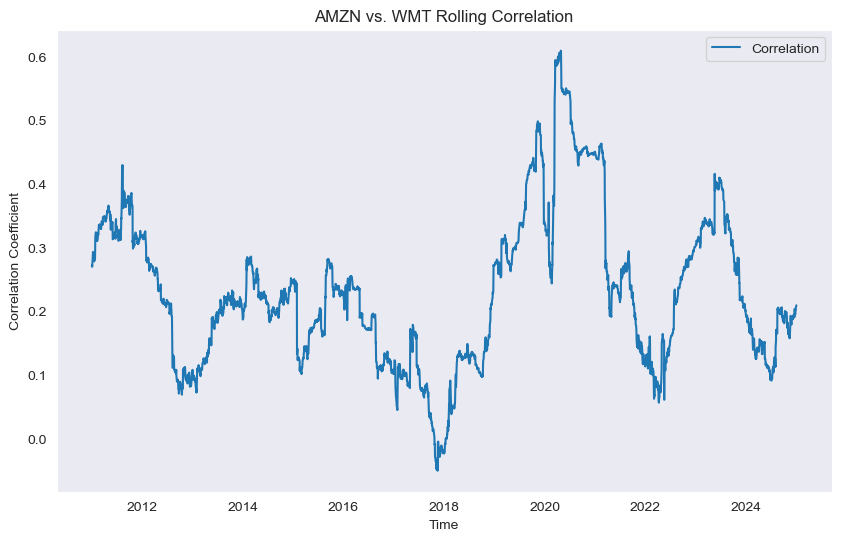

In [32]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(rolling_corr, label='Correlation', alpha=1)

# Config
plt.title('AMZN vs. WMT Rolling Correlation')
plt.xlabel('Time')
plt.ylabel('Correlation Coefficient') 
plt.legend()
plt.grid()

# Show
plt.show()

In [33]:
# Obtain Residual Returns from Both
residual_returns = pd.read_csv(r'additional_data/capm_residual_returns.csv')
residual_returns.set_index('Date', inplace=True)
residual_returns.index.name = 'date'
residual_returns.index = pd.to_datetime(residual_returns.index)
residual_returns = residual_returns[stock_tickers].loc['2010-01-05':]

residual_returns

,AMZN,WMT
date,,
2010-01-05,0.003341,-0.011057
2010-01-06,-0.018743,-0.002482
2010-01-07,-0.020401,-0.000771
2010-01-08,0.024373,-0.006033
2010-01-11,-0.025759,0.015738
...,...,...
2024-12-24,0.000603,0.021982
2024-12-26,-0.008069,0.001224
2024-12-27,0.002669,-0.008741


In [34]:
residual_returns.corr()

,AMZN,WMT
AMZN,1.000000,-0.030163
WMT,-0.030163,1.000000


In [35]:
res_rolling_corr = residual_returns['AMZN'].rolling(window=252).corr(residual_returns['WMT'])

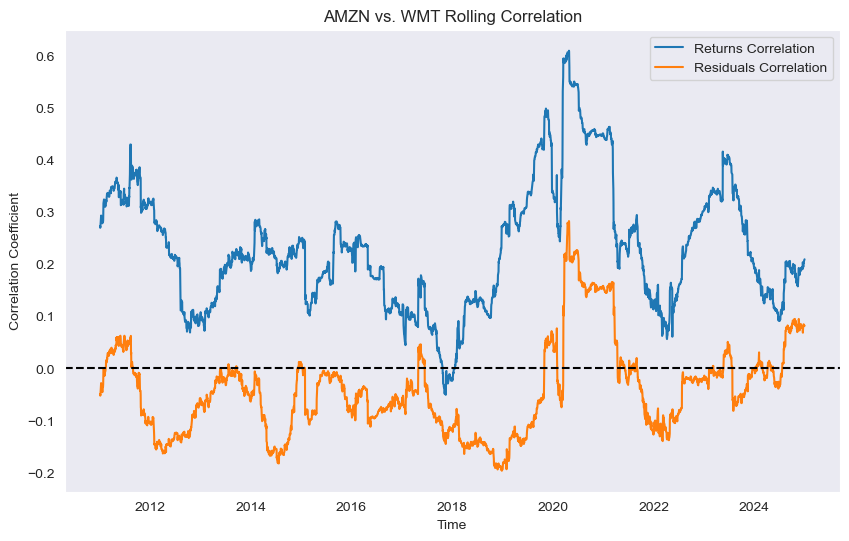

In [36]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(rolling_corr, label='Returns Correlation', alpha=1)
plt.plot(res_rolling_corr, label='Residuals Correlation', alpha=1)
plt.axhline(y=0, color='black', linestyle='dashed')

# Config
plt.title('AMZN vs. WMT Rolling Correlation')
plt.xlabel('Time')
plt.ylabel('Correlation Coefficient') 
plt.legend()
plt.grid()

# Show
plt.show()

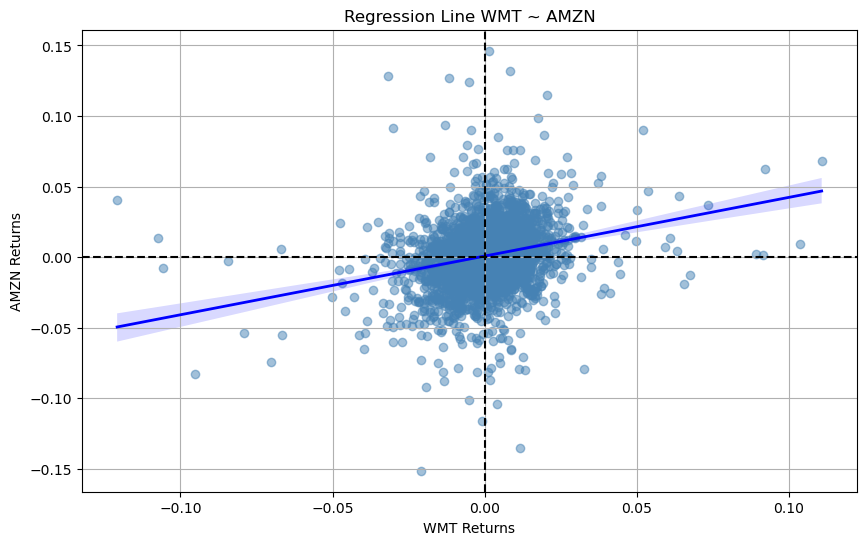

In [91]:
# Scatter Plot with Regression Line
plt.figure(figsize=(10,6))
sns.regplot(
    data=stock_returns,                                         # DataFrame
    x="WMT",                                                    # X-Variable
    y="AMZN",                                                   # Y-Variable
    scatter_kws={"alpha":0.5, "color":"steelblue"},             # Scatter Points
    line_kws={"color":"blue", "lw":2},                          # Regression Line
    ci=95                                                       # Confidence Interval
)

# Vertical and Horizontal Lines
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

plt.title("Regression Line WMT ~ AMZN")
plt.xlabel("WMT Returns")
plt.ylabel("AMZN Returns")
plt.grid()
plt.show()

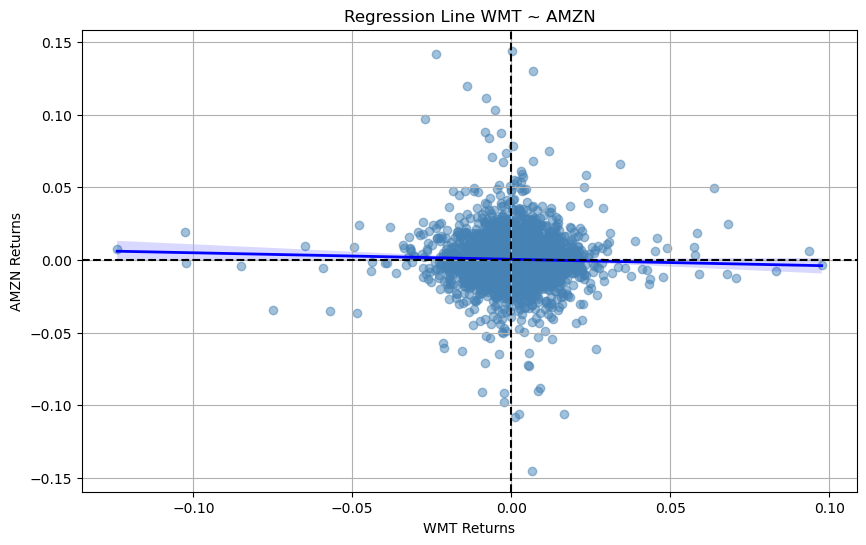

In [92]:
# Scatter Plot with Regression Line
plt.figure(figsize=(10,6))
sns.regplot(
    data=residual_returns,                                         # DataFrame
    x="WMT",                                                    # X-Variable
    y="AMZN",                                                   # Y-Variable
    scatter_kws={"alpha":0.5, "color":"steelblue"},             # Scatter Points
    line_kws={"color":"blue", "lw":2},                          # Regression Line
    ci=95                                                       # Confidence Interval
)

# Vertical and Horizontal Lines
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)

plt.title("Regression Line WMT ~ AMZN")
plt.xlabel("WMT Returns")
plt.ylabel("AMZN Returns")
plt.grid()
plt.show()

In [95]:
stock_returns['AMZN'].corr(index_returns['SPY'])

0.6012504389452348

In [96]:
stock_returns['WMT'].corr(index_returns['SPY'])

0.4429248275186059

In [98]:
amzn_rollcorr_market = stock_returns['AMZN'].rolling(window=252).corr(index_returns['SPY'])
wmt_rollcorr_market = stock_returns['WMT'].rolling(window=252).corr(index_returns['SPY'])

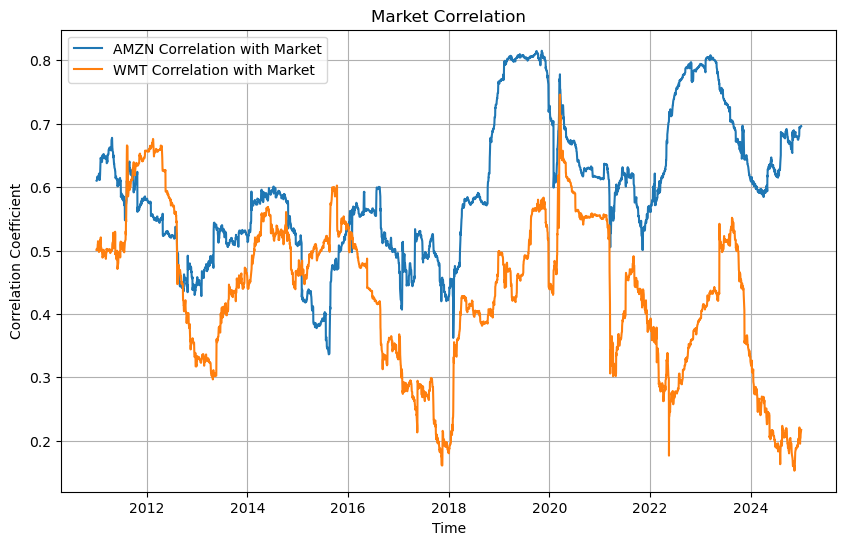

In [102]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(amzn_rollcorr_market, label='AMZN Correlation with Market', alpha=1)
plt.plot(wmt_rollcorr_market, label='WMT Correlation with Market', alpha=1)

# Config
plt.title('Market Correlation')
plt.xlabel('Time')
plt.ylabel('Correlation Coefficient') 
plt.legend()
plt.grid()

# Show
plt.show()

Mencionar:

1) Por qué las correlaciones cambian con o sin el mercado
2) Por qué las correlaciones cambian con el tiempo
3) Existen implicaciones conductuales/institucionales

In [37]:
amzn_rollcorr_res_market = residual_returns['AMZN'].rolling(window=252).corr(index_returns['SPY'])
wmt_rollcorr_res_market = residual_returns['WMT'].rolling(window=252).corr(index_returns['SPY'])

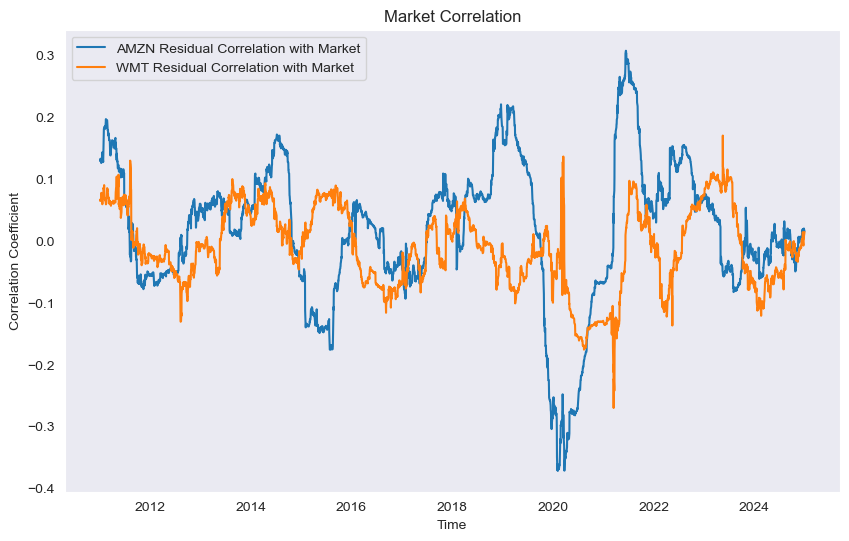

In [38]:
# Create Plot
plt.figure(figsize=(10, 6))
plt.plot(amzn_rollcorr_res_market, label='AMZN Residual Correlation with Market', alpha=1)
plt.plot(wmt_rollcorr_res_market, label='WMT Residual Correlation with Market', alpha=1)

# Config
plt.title('Market Correlation')
plt.xlabel('Time')
plt.ylabel('Correlation Coefficient') 
plt.legend()
plt.grid()

# Show
plt.show()